# Day 10: Data Loading & Preprocessing

> **Goal:** Master PyTorch's `Dataset`, `DataLoader`, and `transforms` pipeline. Load MNIST as your first real dataset.

---

## Why This Matters

So far we've trained on tiny tensors that fit entirely in memory. Real datasets are:
- **Too large** to load all at once
- **Need preprocessing** (normalization, augmentation, resizing)
- **Must be batched** for efficient GPU utilization

PyTorch's data pipeline solves all of this:

```
Dataset → DataLoader → batches of (input, target)
```

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

---
## 1. The `Dataset` Class

A PyTorch `Dataset` must implement:

| Method | Purpose |
|---|---|
| `__len__()` | Return the total number of samples |
| `__getitem__(idx)` | Return one sample as `(input, target)` |

Let's build a custom one first to understand the interface.

In [2]:
class SyntheticDataset(Dataset):
    """A simple dataset: y = 2*x + 3 + noise."""

    def __init__(self, n_samples=1000):
        self.x = torch.randn(n_samples, 1)
        self.y = 2 * self.x + 3 + 0.1 * torch.randn(n_samples, 1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


dataset = SyntheticDataset(500)
print(f"Dataset size: {len(dataset)}")
print(f"First sample: x={dataset[0][0].item():.3f}, y={dataset[0][1].item():.3f}")

Dataset size: 500
First sample: x=1.927, y=7.005


---
## 2. The `DataLoader` — Batching, Shuffling, and More

`DataLoader` wraps a `Dataset` and provides:
- **Batching** — groups samples together
- **Shuffling** — randomises order each epoch (important for training!)
- **Parallel loading** — `num_workers` for multi-process data loading
- **Drop last** — discard incomplete final batch

In [3]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(loader)
print(enumerate(loader))

# Iterate over one epoch
for i, (x_batch, y_batch) in enumerate(loader):
    if i < 3:  # show first 3 batches
        print(f"Batch {i}: x shape={x_batch.shape}, y shape={y_batch.shape}")

print(f"\nTotal batches per epoch: {len(loader)}")
print(f"Batch size: 32, Dataset size: {len(dataset)} → {len(dataset)//32} full batches + 1 partial")

Batch 0: x shape=torch.Size([32, 1]), y shape=torch.Size([32, 1])
Batch 1: x shape=torch.Size([32, 1]), y shape=torch.Size([32, 1])
Batch 2: x shape=torch.Size([32, 1]), y shape=torch.Size([32, 1])

Total batches per epoch: 16
Batch size: 32, Dataset size: 500 → 15 full batches + 1 partial


---
## 3. Transforms — Preprocessing Pipeline

`torchvision.transforms` provides composable image transformations:

| Transform | What it does |
|---|---|
| `ToTensor()` | PIL Image / numpy → tensor, scales [0,255] → [0,1] |
| `Normalize(mean, std)` | Standardize: `(x - mean) / std` |
| `Resize(size)` | Resize to given size |
| `Compose([...])` | Chain multiple transforms |

In [4]:
# A typical transform pipeline for MNIST
transform = transforms.Compose([
    transforms.ToTensor(),                # PIL → tensor, [0,255] → [0,1]
    transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean & std
])

print("Transform pipeline:", transform)

Transform pipeline: Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)


### Why Normalize?

- Neural networks train better when inputs have **zero mean** and **unit variance**.
- The values 0.1307 and 0.3081 are the **pre-computed mean and std** of the MNIST dataset.
- Think of it like calibrating a sensor — you remove the bias and scale.

---
## 4. Loading MNIST — Your First Real Dataset 🎉

MNIST = 70,000 handwritten digit images (28×28 grayscale), 10 classes (0–9).

In [5]:
# Download and load MNIST
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Image shape:      {train_dataset[0][0].shape}")  # (C, H, W)
print(f"Label type:       {type(train_dataset[0][1])}")
print(f"Classes:          {train_dataset.classes}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 389kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.92MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.93MB/s]

Training samples: 60000
Test samples:     10000
Image shape:      torch.Size([1, 28, 28])
Label type:       <class 'int'>
Classes:          ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


### Exploring the Data

Let's visualize some digits and check the pixel statistics after our normalization transform has been applied. After normalization, the pixel values should have approximately zero mean.

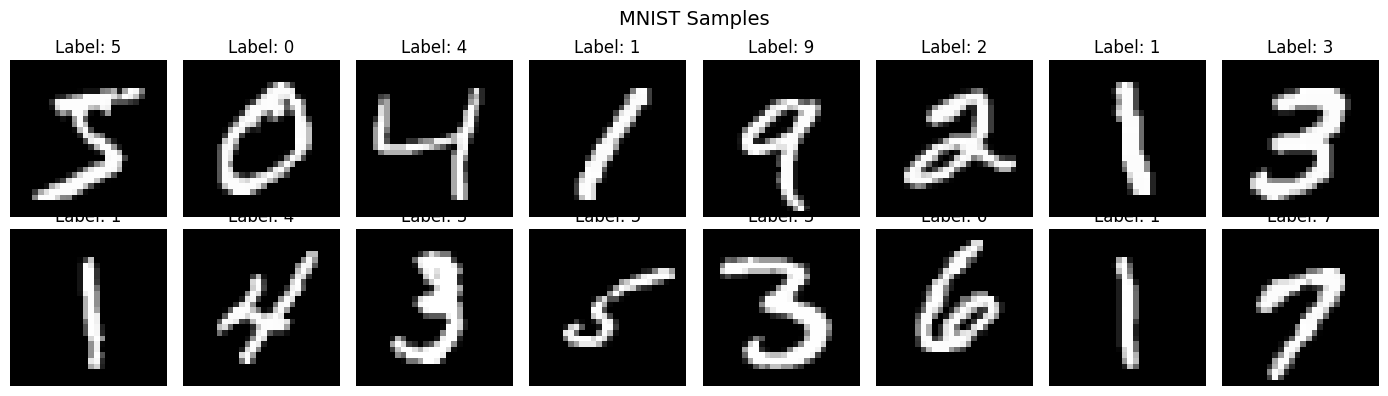

In [6]:
# Visualize some samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    # img shape is (1, 28, 28) — squeeze the channel dim for display
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("MNIST Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Check pixel value statistics after normalization
img, _ = train_dataset[0]
print(f"Min pixel value: {img.min():.4f}")
print(f"Max pixel value: {img.max():.4f}")
print(f"Mean:            {img.mean():.4f}")
print(f"Std:             {img.std():.4f}")

Min pixel value: -0.4242
Max pixel value: 2.8215
Mean:            0.0227
Std:             1.0144


---
## 5. Creating DataLoaders

Now let's wrap the datasets in DataLoaders for training.

In [14]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches:     {len(test_loader)}")

# Peek at one batch
images, labels = next(iter(train_loader))
print(f"\nBatch images shape: {images.shape}")  # (64, 1, 28, 28)
print(f"Batch labels shape: {labels.shape}")    # (64,)

Training batches: 938
Test batches:     157

Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])


### Understanding the Shape: `(B, C, H, W)`

PyTorch uses **channels-first** format:

- **B** = batch size (64)
- **C** = channels (1 for grayscale, 3 for RGB)
- **H** = height (28)
- **W** = width (28)

This is different from NumPy/OpenCV which use `(H, W, C)`.

---
## 6. Train/Validation Split

It's good practice to hold out part of the training data for validation (to detect overfitting).

In [9]:
# Split training set into train + validation
train_size = int(0.8 * len(train_dataset))  # 80% train
val_size = len(train_dataset) - train_size   # 20% validation

train_subset, val_subset = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_subset)}, Val: {len(val_subset)}, Test: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train: 48000, Val: 12000, Test: 10000
Train batches: 750, Val batches: 188


---
## 7. Iterating Through Data — The Training Pattern

Here's what a real training loop looks like with DataLoader (we'll fully build this on Day 11):

In [11]:
# Preview of the training pattern (we'll build the full model tomorrow)
import torch.nn as nn

# Simple linear model for demonstration
simple_model = nn.Linear(28*28, 10)  # 784 inputs → 10 classes
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(simple_model.parameters(), lr=0.01)
print(simple_model.parameters)

# One epoch of training
simple_model.train()
total_loss = 0
correct = 0
total = 0

for batch_idx, (images, labels) in enumerate(train_loader):
    # Flatten images: (B, 1, 28, 28) → (B, 784)
    images = images.view(images.size(0), -1)

    # Forward
    outputs = simple_model(images)
    loss = loss_fn(outputs, labels)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

    if batch_idx % 200 == 0:
        print(f"  Batch {batch_idx:4d}/{len(train_loader)} | Loss: {loss.item():.4f}")

print(f"\nEpoch done! Avg loss: {total_loss/len(train_loader):.4f}, "
      f"Accuracy: {100.*correct/total:.1f}%")

<bound method Module.parameters of Linear(in_features=784, out_features=10, bias=True)>
  Batch    0/750 | Loss: 2.5121
  Batch  200/750 | Loss: 0.5476
  Batch  400/750 | Loss: 0.3947
  Batch  600/750 | Loss: 0.4658

Epoch done! Avg loss: 0.4932, Accuracy: 86.8%


---
## 🧪 Exercises

### Exercise 1: Custom Dataset
Create a `Dataset` for the function `y = sin(x) + noise` with 1000 points. Wrap it in a DataLoader with batch_size=32.

### Exercise 2: Explore batch sizes
Create DataLoaders with batch sizes 1, 16, 64, 256. Print how many batches each creates. How does batch size affect the number of parameter updates per epoch?

### Exercise 3: Visualize without normalization
Load MNIST *without* the `Normalize` transform. Compare the pixel statistics to the normalized version.

### Exercise 4: Class distribution
Count how many samples of each digit (0–9) exist in the training set. Is MNIST balanced? Plot a bar chart.

In [ ]:
# Exercise 1: Your code here

In [ ]:
# Exercise 2: Your code here

In [ ]:
# Exercise 3: Your code here

In [ ]:
# Exercise 4: Your code here

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| `Dataset` | Must implement `__len__` and `__getitem__` |
| `DataLoader` | Handles batching, shuffling, parallel loading |
| `transforms.Compose` | Chain preprocessing steps |
| `ToTensor()` | Converts images to tensors and scales to [0,1] |
| `Normalize(mean, std)` | Standardizes inputs for better training |
| Image shape | PyTorch uses `(B, C, H, W)` — channels first |
| `random_split` | Split dataset into train/val subsets |

**Tomorrow:** We'll build our first real neural network — an MLP that classifies MNIST digits!